# OceanBench field representation benchmark (Data Provider subset)

Benchmark **all implemented OceanBench field representation models** on a **single real ocean subset** loaded via the existing **OceanBench Data Provider**.

Goals:
- Load one subset (`product_id`, `region`, `time window`, `variable`)
- Build a **reproducible** train/test split
- Fit and evaluate **all field models** on the same data
- Compare prediction quality (RMSE/MAE), uncertainty behavior, and runtime
- Visualize truth / mean / uncertainty / error on a continuous lat–lon grid

Note: `STGPFieldModel` is spatio-temporal; here we benchmark on a single time slice by giving it a constant timestamp. A multi-time benchmark would better showcase its temporal modeling.


In [136]:
# Imports and repo path setup
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
for p in [
    'oceanbench-core',
    'oceanbench-env',
    'oceanbench-models',
    'oceanbench-tasks',
    'oceanbench-bench',
    'oceanbench-viz',
    'oceanbench-data-provider',
]:
    d = ROOT / p
    if d.exists() and str(d) not in sys.path:
        sys.path.insert(0, str(d))

import time
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': False})

from oceanbench_core.types import ObservationBatch, QueryPoints
from oceanbench_env import OceanTruthField
from oceanbench_tasks.metrics.common import rmse, mae
from oceanbench_models.belief.field import (
    LocalLinearFieldModel,
    GPFieldModel,
    SparseOnlineGPFieldModel,
    PseudoInputGPFieldModel,
    STGPFieldModel,
    GMRFFieldModel,
)

from oceanbench_data_provider import DataProvider


## Experimental setup

We work on a single real subset from the OceanBench Data Provider. The goal is
to benchmark different field representations on the **same** data:

- Same product / region / time window / variable
- Same train/test split
- Same evaluation grid and metrics

In [137]:
SEED = 42
rng = np.random.default_rng(SEED)

PRODUCT_ID = "copernicus_phy_reanalysis_001_030"
VARIABLE = 'temp'

REGION = {'lon': [-95, -85], 'lat': [22, 27]}
TIME_WINDOW = ('2014-01-01', '2014-01-02')

N_TRAIN = 1000
N_TEST = 300

GRID_N_LAT = 80
GRID_N_LON = 80


In [138]:
provider = DataProvider()
t0 = time.perf_counter()
ds = provider.subset(
    product_id=PRODUCT_ID,
    region=REGION,
    time=TIME_WINDOW,
    variables=[VARIABLE],
)
print(f'Loaded subset in {time.perf_counter() - t0:.2f}s')
ds

Loaded subset in 0.03s


<xarray.Dataset> Size: 6MB
Dimensions:  (time: 2, depth: 50, lat: 61, lon: 121)
Coordinates:
  * time     (time) datetime64[ns] 16B 2014-01-01 2014-01-02
  * depth    (depth) float32 200B 0.494 1.541 2.646 ... 5.275e+03 5.728e+03
  * lat      (lat) float32 244B 22.0 22.08 22.17 22.25 ... 26.83 26.92 27.0
  * lon      (lon) float32 484B -95.0 -94.92 -94.83 ... -85.17 -85.08 -85.0
Data variables:
    temp     (time, depth, lat, lon) float64 6MB 23.98 24.06 24.05 ... nan nan
Attributes: (12/29)
    Conventions:                  CF-1.4
    bulletin_date:                2021-07-07 00:00:00
    bulletin_type:                operational
    comment:                      CMEMS product
    domain_name:                  GL12
    easting:                      longitude
    ...                           ...
    z_min:                        0.49402499198913574
    copernicusmarine_version:     2.3.0
    _var_mapping:                 {'thetao': 'temp'}
    oceanbench_pipeline_version:  v1
    oceanbench_lon_convention:    [-180, 180]
    oceanbench_product_id:        copernicus_phy_reanalysis_001_030

In [139]:
ds_slice = ds
selected_time = None
if 'time' in ds_slice.dims:
    selected_time = ds_slice['time'].values[0]
    ds_slice = ds_slice.isel(time=0)

selected_depth = None
if 'depth' in ds_slice.dims:
    selected_depth = float(ds_slice['depth'].values[0])
    ds_slice = ds_slice.isel(depth=0)

print('selected_time:', selected_time)
print('selected_depth:', selected_depth)
ds_slice

selected_time: 2014-01-01T00:00:00.000000000
selected_depth: 0.49402499198913574


<xarray.Dataset> Size: 60kB
Dimensions:  (lat: 61, lon: 121)
Coordinates:
  * lat      (lat) float32 244B 22.0 22.08 22.17 22.25 ... 26.83 26.92 27.0
  * lon      (lon) float32 484B -95.0 -94.92 -94.83 ... -85.17 -85.08 -85.0
    depth    float32 4B 0.494
    time     datetime64[ns] 8B 2014-01-01
Data variables:
    temp     (lat, lon) float64 59kB 23.98 24.06 24.05 ... 24.56 24.64 24.72
Attributes: (12/29)
    Conventions:                  CF-1.4
    bulletin_date:                2021-07-07 00:00:00
    bulletin_type:                operational
    comment:                      CMEMS product
    domain_name:                  GL12
    easting:                      longitude
    ...                           ...
    z_min:                        0.49402499198913574
    copernicusmarine_version:     2.3.0
    _var_mapping:                 {'thetao': 'temp'}
    oceanbench_pipeline_version:  v1
    oceanbench_lon_convention:    [-180, 180]
    oceanbench_product_id:        copernicus_phy_reanalysis_001_030

## Train/test split

We build a reproducible train/test split directly from the sanitized xarray
grid:

- Flatten `(lat, lon)` and values for the chosen time/depth slice.
- Filter out NaNs.
- Randomly select `N_TRAIN + N_TEST` points with a fixed seed.
- Use the first `N_TRAIN` as training observations, the rest as test points.

In [140]:
da = ds_slice[VARIABLE]
lat_vals = np.asarray(ds_slice['lat'].values, dtype=float)
lon_vals = np.asarray(ds_slice['lon'].values, dtype=float)
Lat, Lon = np.meshgrid(lat_vals, lon_vals, indexing='ij')
Y = np.asarray(da.values, dtype=float)

flat_lat = Lat.ravel()
flat_lon = Lon.ravel()
flat_y = Y.ravel()

valid = np.isfinite(flat_y)
flat_lat = flat_lat[valid]
flat_lon = flat_lon[valid]
flat_y = flat_y[valid]

n_total = N_TRAIN + N_TEST
if flat_y.size < n_total:
    raise ValueError('Not enough valid grid points for requested N_TRAIN+N_TEST')

idx = rng.choice(flat_y.size, size=n_total, replace=False)
train_idx = idx[:N_TRAIN]
test_idx = idx[N_TRAIN:]

train_obs = ObservationBatch(
    lats=flat_lat[train_idx],
    lons=flat_lon[train_idx],
    values=flat_y[train_idx],
    variable=VARIABLE,
)
test_qp = QueryPoints(lats=flat_lat[test_idx], lons=flat_lon[test_idx])
y_test_true = flat_y[test_idx]

print('train_obs.size:', train_obs.size)
print('test_qp.size:', test_qp.size)

train_obs.size: 1000
test_qp.size: 300


In [141]:
lat_min, lat_max = float(lat_vals.min()), float(lat_vals.max())
lon_min, lon_max = float(lon_vals.min()), float(lon_vals.max())

grid_lat = np.linspace(lat_min, lat_max, GRID_N_LAT)
grid_lon = np.linspace(lon_min, lon_max, GRID_N_LON)
GridLat, GridLon = np.meshgrid(grid_lat, grid_lon, indexing='ij')

grid_qp = QueryPoints(lats=GridLat.ravel(), lons=GridLon.ravel())
truth = OceanTruthField(dataset=ds_slice, variable=VARIABLE)
y_grid_true = truth.query_array(grid_qp, bounds_mode='clip')
Y_grid_true = y_grid_true.reshape(GRID_N_LAT, GRID_N_LON)

print('Grid truth shape:', Y_grid_true.shape)

Grid truth shape: (80, 80)


## Models compared

We include all currently implemented field models:

- Local Linear Regression
- Full Gaussian Process (GP)
- Sparse Online GP
- Pseudo-Input GP (FITC-style)
- Spatio-Temporal GP (STGP) with a constant time stamp in this slice
- Gaussian Markov Random Field (GMRF)

In [142]:
models = [
    (
        'local_linear',
        LocalLinearFieldModel(
            {
                # LocalLinearFieldModel config
                'k_neighbors': 30,
                'include_time': True,
                'include_depth': True,
                # (no optimizer / lr / device; this model is pure sklearn)
            },
            seed=SEED,
        ),
    ),
    (
        'gp',
        GPFieldModel(
            {
                # Shared GP hyperparameters
                'lengthscale': 0.25,
                'variance': 1.0,
                'noise': 0.05,
                # Feature handling
                'include_time': True,
                'include_depth': True,
                'use_scaling': True,
                # Training / optimization
                'training_iters': 300,   # 0 = no training (fixed hyperparams)
                'lr': 0.1,
                # Device
                'device': 'cpu',        # e.g. 'cpu', 'cuda', 'cuda:0'
            },
            seed=SEED,
        ),
    ),
    (
        'stgp',
        STGPFieldModel(
            {
                # Spatio-temporal kernel hyperparameters
                'lengthscale_space': 0.25,
                'lengthscale_time': 86400.0,   # seconds, as in your original code
                # These come via parse_gp_hyperparams
                'variance': 1.0,
                'noise': 0.05,
                # Feature handling
                'include_depth': True,
                'use_scaling': True,
                # Training / optimization
                'training_iters': 300,          # 0 = no training
                'lr': 0.1,
                # Device
                'device': 'cpu',
            },
            seed=SEED,
        ),
    ),
    (
        'sparse_online_gp',
        SparseOnlineGPFieldModel(
            {
                # Inducing / variational config
                'n_pseudo': min(150, N_TRAIN),
                # Shared GP hyperparameters
                'lengthscale': 0.25,
                'variance': 1.0,
                'noise': 0.05,
                # Feature handling
                'include_time': True,
                'include_depth': True,
                'use_scaling': True,
                # Training / optimization
                'training_iters': 1000,   # initial fit
                'update_iters': 30,     # per-update mini-batch
                'lr': 0.1,
                # Device
                'device': 'cpu',
            },
            seed=SEED,
        ),
    ),
    (
        'pseudo_input_gp',
        PseudoInputGPFieldModel(
            {
                # Inducing / variational config
                'n_pseudo': min(150, N_TRAIN),
                # Shared GP hyperparameters
                'lengthscale': 0.25,
                'variance': 1.0,
                'noise': 0.05,
                # Feature handling
                'include_time': True,
                'include_depth': True,
                'use_scaling': True,
                # Training / optimization
                'training_iters': 1000,
                'lr': 0.1,
                # Device
                'device': 'cpu',
            },
            seed=SEED,
        ),
    ),
    (
        'gmrf',
        GMRFFieldModel(
            {
                # Grid / prior config
                'n_lat': 50,
                'n_lon': 50,
                'obs_noise': 0.05,
                'prior_precision_scale': 1.0,
                # Extra flags (currently not used for grid, but exposed)
                'include_time': False,
                'include_depth': False,
            },
            seed=SEED,
        ),
    ),
]

[(name, m.supports_uncertainty, m.supports_online_update) for name, m in models]

[('local_linear', False, False),
 ('gp', True, False),
 ('stgp', True, False),
 ('sparse_online_gp', True, True),
 ('pseudo_input_gp', True, False),
 ('gmrf', True, False)]

In [143]:
# models = [
#     ('local_linear', LocalLinearFieldModel({'k_neighbors': 30, 'min_neighbors': 5}, seed=SEED)),
#     ('gp', GPFieldModel({'lengthscale': 0.25, 'variance': 1.0, 'noise': 0.05}, seed=SEED)),
#     ('sparse_online_gp', SparseOnlineGPFieldModel({'max_points': min(400, N_TRAIN)}, seed=SEED)),
#     ('pseudo_input_gp', PseudoInputGPFieldModel({'n_pseudo': min(150, N_TRAIN)}, seed=SEED)),
#     ('stgp', STGPFieldModel({'lengthscale_space': 0.25, 'lengthscale_time': 86400.0, 'noise': 0.05}, seed=SEED)),
#     ('gmrf', GMRFFieldModel({'n_lat': 50, 'n_lon': 50, 'obs_noise': 0.05}, seed=SEED)),
# ]

# [(name, m.supports_uncertainty, m.supports_online_update) for name, m in models]

## Evaluation and visualization

For each model we record:

- RMSE/MAE on **held-out test points**
- RMSE on the **evaluation grid**
- Fit and prediction runtimes
- Uncertainty diagnostics where available

We visualize:

- Truth field on the grid
- Predicted mean field
- Predicted standard deviation
- Error field (prediction − truth)

All mean maps (including truth) share the same colorbar; all std maps share one
colorbar; all error maps share a symmetric colorbar.

In [144]:
def _with_constant_time(obs: ObservationBatch, qp: QueryPoints, t0):
    times_obs = np.full(obs.size, t0, dtype='datetime64[ns]')
    times_qp = np.full(qp.size, t0, dtype='datetime64[ns]')
    obs_t = ObservationBatch(
        lats=obs.lats,
        lons=obs.lons,
        values=obs.values,
        variable=obs.variable,
        times=times_obs,
    )
    qp_t = QueryPoints(lats=qp.lats, lons=qp.lons, times=times_qp)
    return obs_t, qp_t

results = {}

for name, model in models:
    model.reset()
    model.seed(SEED)

    if name == 'stgp':
        if selected_time is None:
            t_const = np.datetime64('2014-01-01')
        else:
            t_const = np.datetime64(selected_time).astype('datetime64[ns]')
        train_obs_use, test_qp_use = _with_constant_time(train_obs, test_qp, t_const)
        _, grid_qp_use = _with_constant_time(train_obs, grid_qp, t_const)
    else:
        train_obs_use, test_qp_use = train_obs, test_qp
        grid_qp_use = grid_qp

    t0 = time.perf_counter()
    model.fit(train_obs_use)
    fit_s = time.perf_counter() - t0

    t0 = time.perf_counter()
    pred_test = model.predict(test_qp_use)
    pred_s = time.perf_counter() - t0

    y_test_pred = np.asarray(pred_test.mean, dtype=float).ravel()
    metrics = {
        'rmse_test': rmse(y_test_true, y_test_pred),
        'mae_test': mae(y_test_true, y_test_pred),
        'fit_s': fit_s,
        'predict_test_s': pred_s,
        'supports_uncertainty': bool(model.supports_uncertainty),
        'supports_online_update': bool(model.supports_online_update),
    }

    if model.supports_uncertainty and pred_test.std is not None:
        std_test = np.asarray(pred_test.std, dtype=float).ravel()
        err = np.abs(y_test_true - y_test_pred)
        valid = np.isfinite(std_test) & np.isfinite(err) & (std_test >= 0)
        if np.any(valid):
            coverage_2std = float(np.mean(err[valid] <= 2.0 * std_test[valid]))
            corr = float(np.corrcoef(err[valid], std_test[valid])[0, 1]) if valid.sum() > 2 else float('nan')
        else:
            coverage_2std, corr = float('nan'), float('nan')
        metrics['coverage_|err|<=2std'] = coverage_2std
        metrics['corr(|err|, std)'] = corr
    else:
        metrics['coverage_|err|<=2std'] = None
        metrics['corr(|err|, std)'] = None

    t0 = time.perf_counter()
    pred_grid = model.predict(grid_qp_use)
    grid_pred_s = time.perf_counter() - t0
    Y_grid_pred = np.asarray(pred_grid.mean, dtype=float).reshape(GRID_N_LAT, GRID_N_LON)
    Y_grid_std = None
    if model.supports_uncertainty and pred_grid.std is not None:
        Y_grid_std = np.asarray(pred_grid.std, dtype=float).reshape(GRID_N_LAT, GRID_N_LON)

    metrics['predict_grid_s'] = grid_pred_s
    metrics['rmse_grid'] = float(np.sqrt(np.nanmean((Y_grid_true - Y_grid_pred) ** 2)))

    results[name] = {
        'model': model,
        'metrics': metrics,
        'pred_test': pred_test,
        'Y_grid_pred': Y_grid_pred,
        'Y_grid_std': Y_grid_std,
    }

results.keys()

/home/shafezi/Documents/Projects/Data_Provider/oceanbench/oceanbench-venv/lib/python3.12/site-packages/torch/_compile.py:54: UserWarning: optimizer contains a parameter group with duplicate parameters; in future, this will cause an error; see github.com/pytorch/pytorch/issues/40967 for more information
  return disable_fn(*args, **kwargs)


dict_keys(['local_linear', 'gp', 'stgp', 'sparse_online_gp', 'pseudo_input_gp', 'gmrf'])

In [145]:
# Shared color scales (raw global ranges; no percentile clipping)
all_means = [Y_grid_true] + [results[name]['Y_grid_pred'] for name in results]
all_means_flat = np.concatenate([Z.ravel() for Z in all_means])
mean_vmin = float(np.nanmin(all_means_flat))
mean_vmax = float(np.nanmax(all_means_flat))

std_arrays = [results[name]['Y_grid_std'] for name in results if results[name]['Y_grid_std'] is not None]
if std_arrays:
    all_std_flat = np.concatenate([S.ravel() for S in std_arrays])
    std_vmin = float(np.nanmin(all_std_flat))
    std_vmax = float(np.nanmax(all_std_flat))
else:
    std_vmin = std_vmax = None

all_err = []
for name in results:
    Y_pred = results[name]['Y_grid_pred']
    all_err.append((Y_pred - Y_grid_true).ravel())
all_err_flat = np.concatenate(all_err)
err_vmin = float(np.nanmin(all_err_flat))
err_vmax = float(np.nanmax(all_err_flat))

mean_vmin, mean_vmax, std_vmin, std_vmax, err_vmin, err_vmax

(20.931379318237305,
 28.077077865600586,
 0.06961733172117819,
 1.809902016654304,
 -1.3951812848196639,
 1.589212826561166)

In [146]:
for name in results:
    m = results[name]['metrics']
    print(
        f"{name:>16} | rmse_test={m['rmse_test']:.4f}  mae_test={m['mae_test']:.4f}  rmse_grid={m['rmse_grid']:.4f}  "
        f"fit={m['fit_s']:.3f}s  pred_test={m['predict_test_s']:.3f}s  pred_grid={m['predict_grid_s']:.3f}s  "
        f"uncert={m['supports_uncertainty']}  online={m['supports_online_update']}"
    )
    if m['coverage_|err|<=2std'] is not None:
        print(
            f"{'':>16} | coverage(|err|<=2std)={m['coverage_|err|<=2std']:.3f}  corr(|err|,std)={m['corr(|err|, std)']:.3f}"
        )

    local_linear | rmse_test=0.2582  mae_test=0.1839  rmse_grid=0.2464  fit=0.001s  pred_test=0.002s  pred_grid=0.016s  uncert=False  online=False
              gp | rmse_test=0.1472  mae_test=0.1070  rmse_grid=0.1518  fit=10.674s  pred_test=0.063s  pred_grid=0.045s  uncert=True  online=False
                 | coverage(|err|<=2std)=1.000  corr(|err|,std)=0.148
            stgp | rmse_test=0.1472  mae_test=0.1070  rmse_grid=0.1518  fit=10.513s  pred_test=0.066s  pred_grid=0.050s  uncert=True  online=False
                 | coverage(|err|<=2std)=1.000  corr(|err|,std)=0.148
sparse_online_gp | rmse_test=0.4347  mae_test=0.3387  rmse_grid=0.4276  fit=12.869s  pred_test=0.008s  pred_grid=0.005s  uncert=True  online=True
                 | coverage(|err|<=2std)=0.413  corr(|err|,std)=0.033
 pseudo_input_gp | rmse_test=0.4347  mae_test=0.3387  rmse_grid=0.4276  fit=13.217s  pred_test=0.007s  pred_grid=0.005s  uncert=True  online=False
                 | coverage(|err|<=2std)=0.413  corr(|er

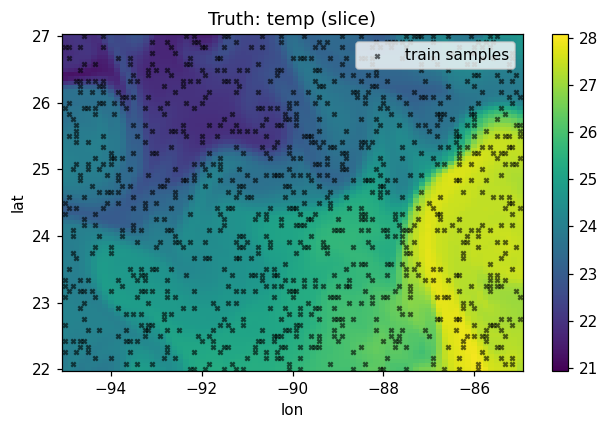

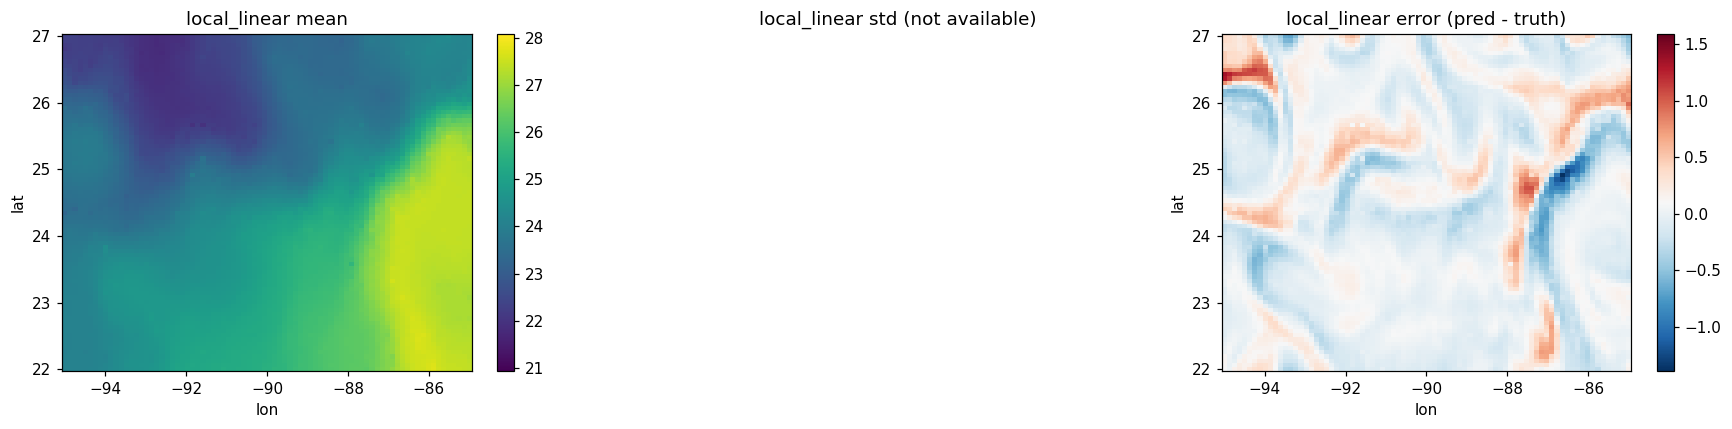

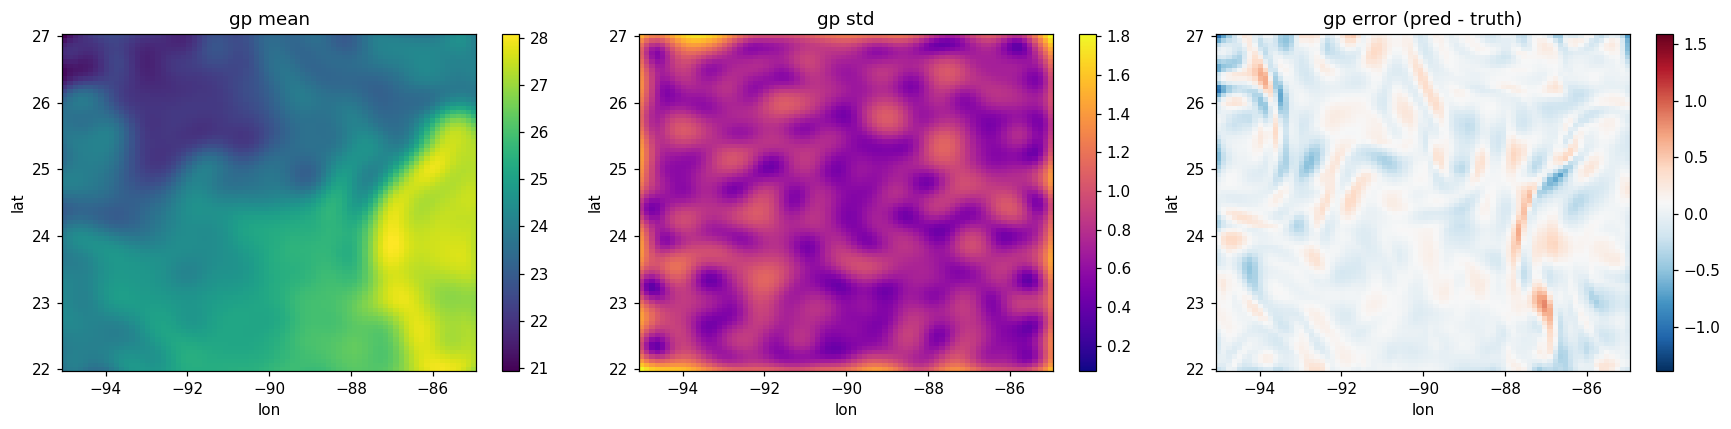

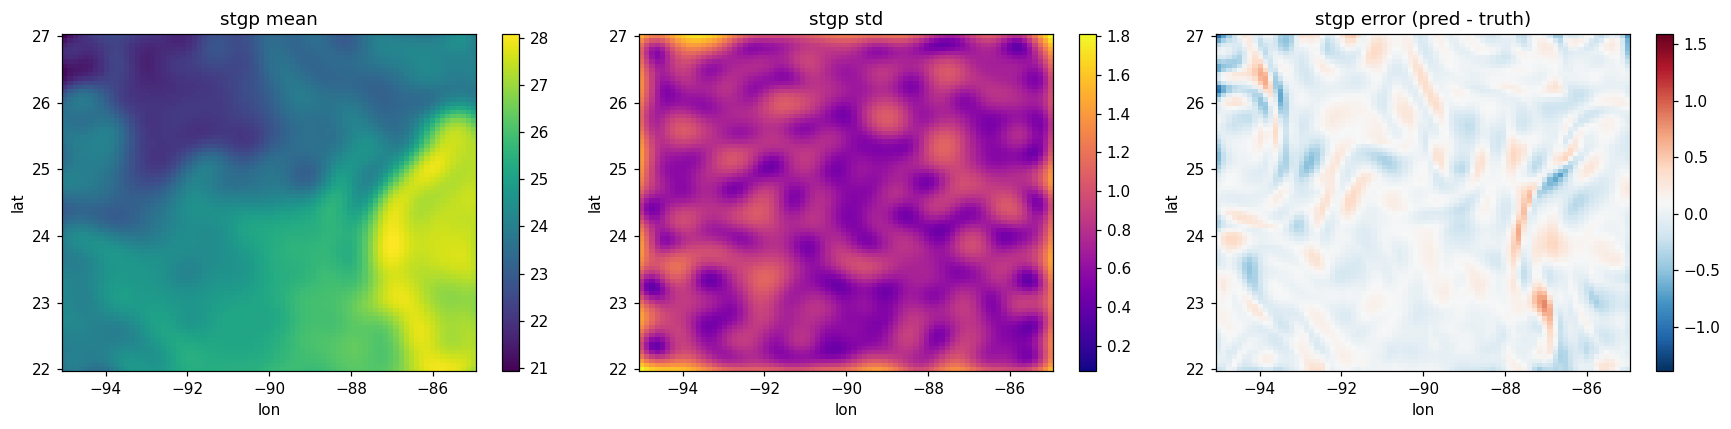

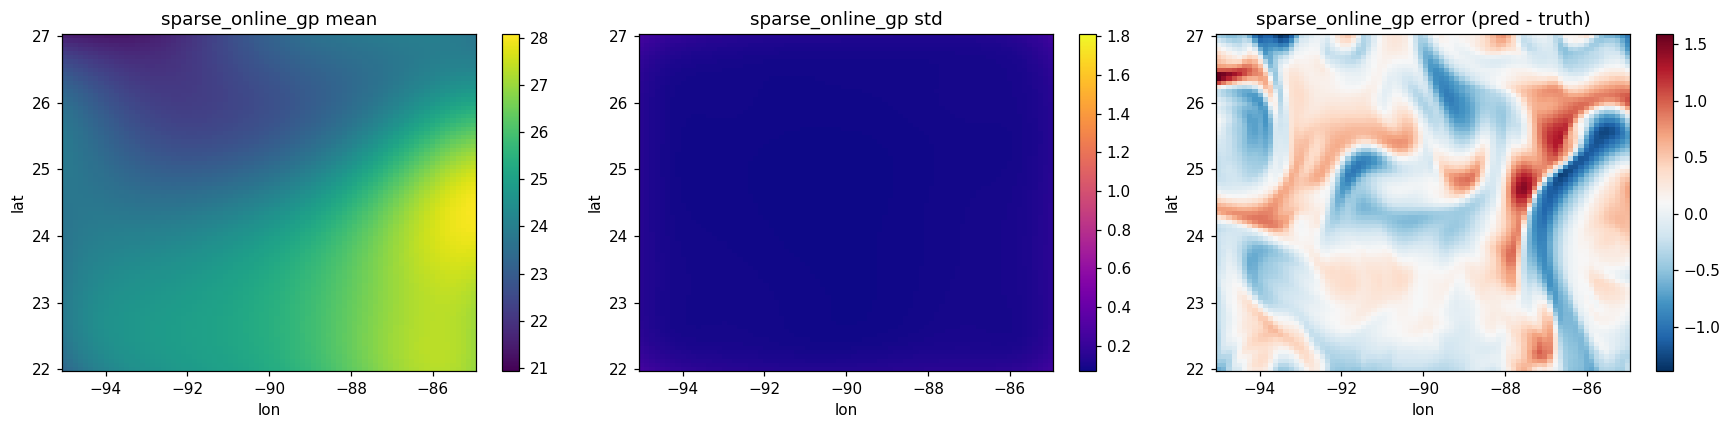

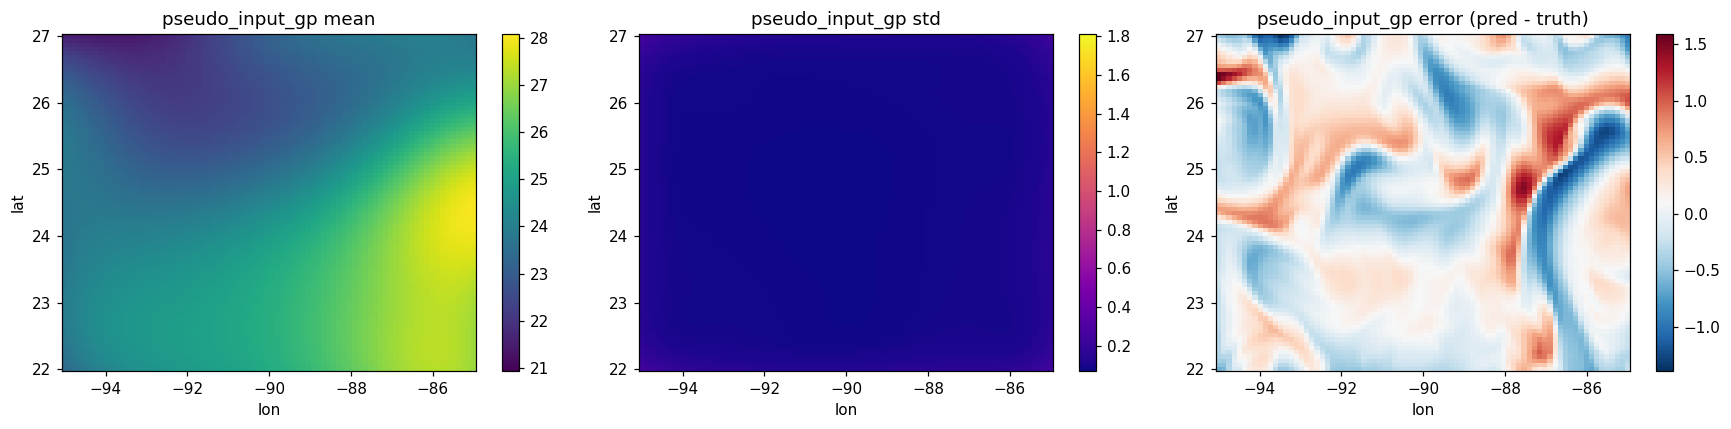

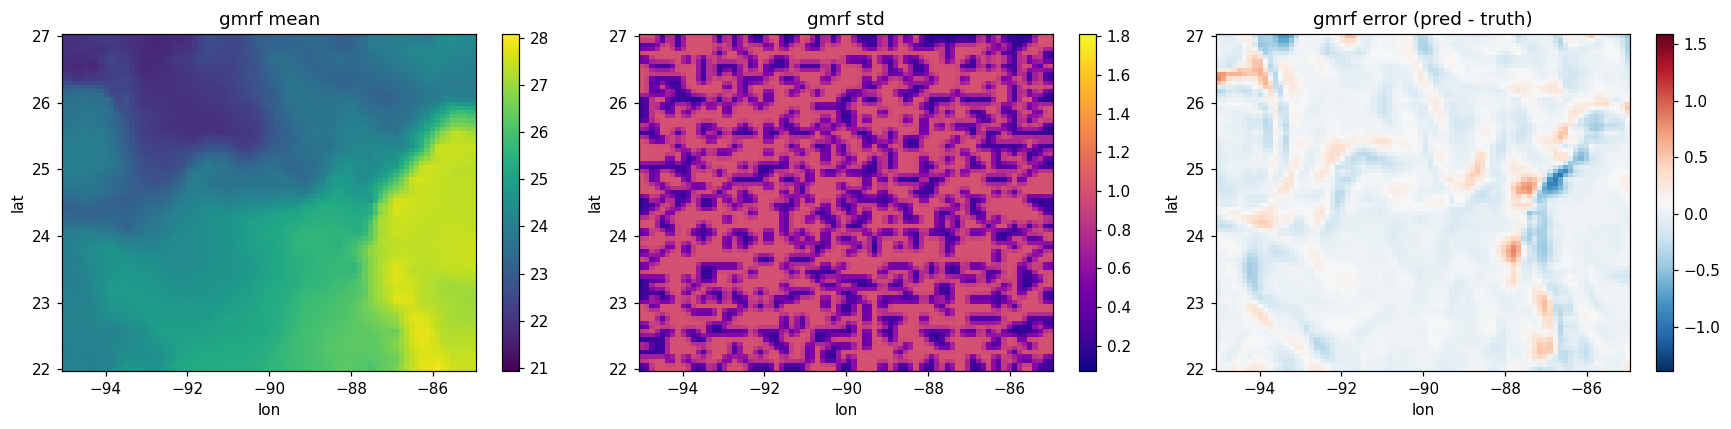

In [147]:
# Truth map with shared mean colorbar
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
pc = ax.pcolormesh(
    GridLon,
    GridLat,
    Y_grid_true,
    shading='auto',
    cmap='viridis',
    vmin=mean_vmin,
    vmax=mean_vmax,
)
ax.set_title(f'Truth: {VARIABLE} (slice)')
ax.set_xlabel('lon')
ax.set_ylabel('lat')
ax.scatter(train_obs.lons, train_obs.lats, s=8, c='k', marker='x', alpha=0.6, label='train samples')
ax.legend(loc='upper right')
plt.colorbar(pc, ax=ax)
plt.tight_layout()
plt.show()

# Per-model mean / std / error with shared colorbars
for name in results:
    Y_pred = results[name]['Y_grid_pred']
    Y_std = results[name]['Y_grid_std']
    err = Y_pred - Y_grid_true

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    pc0 = axes[0].pcolormesh(
        GridLon,
        GridLat,
        Y_pred,
        shading='auto',
        cmap='viridis',
        vmin=mean_vmin,
        vmax=mean_vmax,
    )
    axes[0].set_title(f'{name} mean')
    plt.colorbar(pc0, ax=axes[0])

    if Y_std is not None and std_vmax is not None:
        pc1 = axes[1].pcolormesh(
            GridLon,
            GridLat,
            Y_std,
            shading='auto',
            cmap='plasma',
            vmin=std_vmin,
            vmax=std_vmax,
        )
        axes[1].set_title(f'{name} std')
        plt.colorbar(pc1, ax=axes[1])
    else:
        axes[1].axis('off')
        axes[1].set_title(f'{name} std (not available)')

    pc2 = axes[2].pcolormesh(
        GridLon,
        GridLat,
        err,
        shading='auto',
        cmap='RdBu_r',
        vmin=err_vmin,
        vmax=err_vmax,
    )
    axes[2].set_title(f'{name} error (pred - truth)')
    plt.colorbar(pc2, ax=axes[2])

    for ax in axes:
        ax.set_xlabel('lon')
        ax.set_ylabel('lat')
    plt.tight_layout()
    plt.show()

In [148]:
for name, r in results.items():
    pred = r["pred_test"]
    y_pred = np.asarray(pred.mean).ravel()
    err = np.abs(y_test_true - y_pred)
    print(f"\n{name}")
    print("  error p50/p90/p99:", np.nanpercentile(err, [50, 90, 99]))
    if pred.std is not None:
        std = np.asarray(pred.std).ravel()
        print("  std   p50/p90/p99:", np.nanpercentile(std, [50, 90, 99]))
        cov2 = np.mean(err <= 2*std)
        print("  coverage |err|<=2*std:", cov2)


local_linear
  error p50/p90/p99: [0.1242293  0.44123967 0.73084653]

gp
  error p50/p90/p99: [0.08101118 0.24589469 0.41461659]
  std   p50/p90/p99: [0.72883525 0.95730369 1.25674282]
  coverage |err|<=2*std: 1.0

stgp
  error p50/p90/p99: [0.08101118 0.24589469 0.41461659]
  std   p50/p90/p99: [0.72883525 0.95730369 1.25674282]
  coverage |err|<=2*std: 1.0

sparse_online_gp
  error p50/p90/p99: [0.27383437 0.75965168 1.07645272]
  std   p50/p90/p99: [0.08775349 0.12588718 0.17643613]
  coverage |err|<=2*std: 0.41333333333333333

pseudo_input_gp
  error p50/p90/p99: [0.27383437 0.75965168 1.07645272]
  std   p50/p90/p99: [0.08775349 0.12588718 0.17643613]
  coverage |err|<=2*std: 0.41333333333333333

gmrf
  error p50/p90/p99: [0.05647552 0.25734435 0.50970826]
  std   p50/p90/p99: [0.79102474 1.         1.        ]
  coverage |err|<=2*std: 1.0


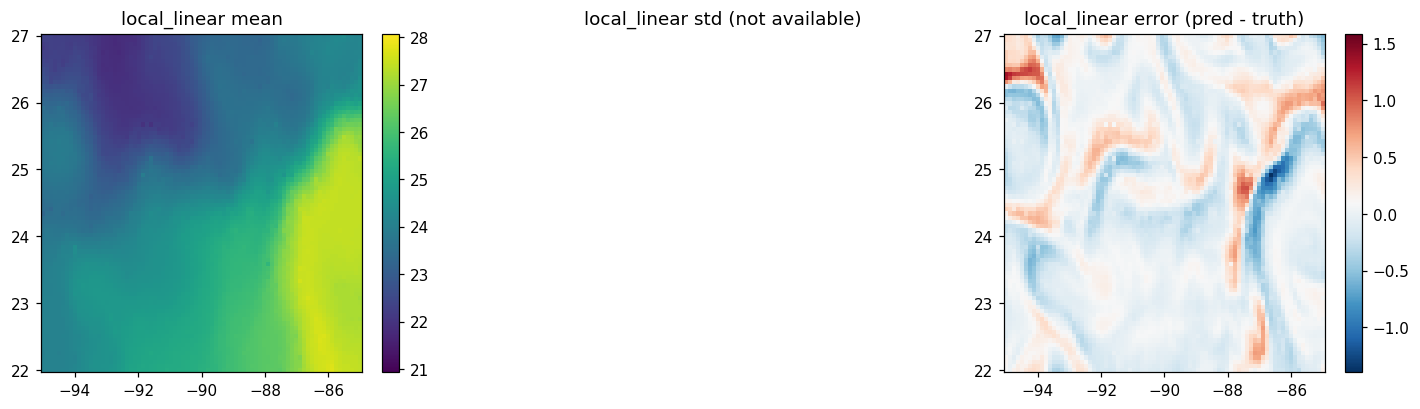

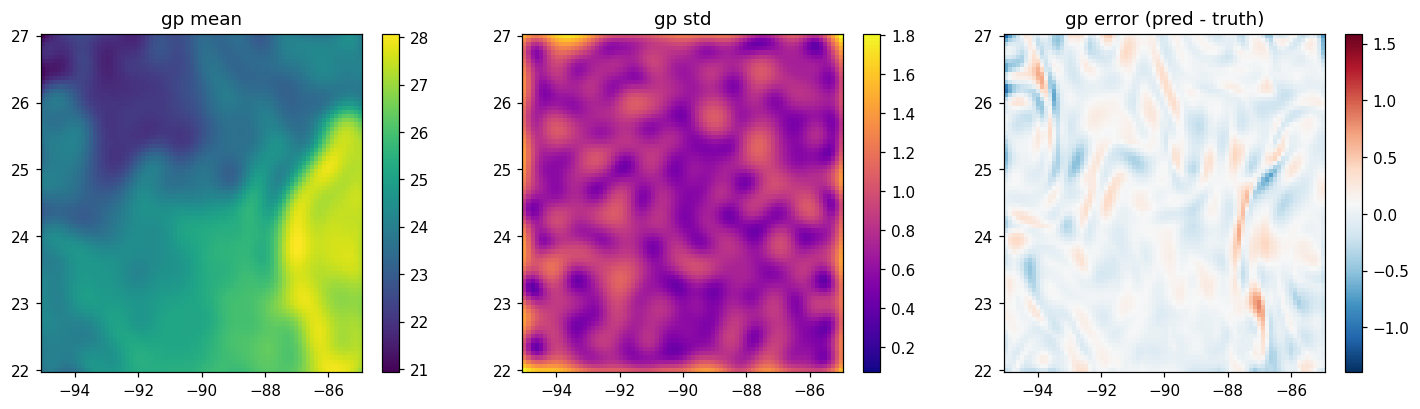

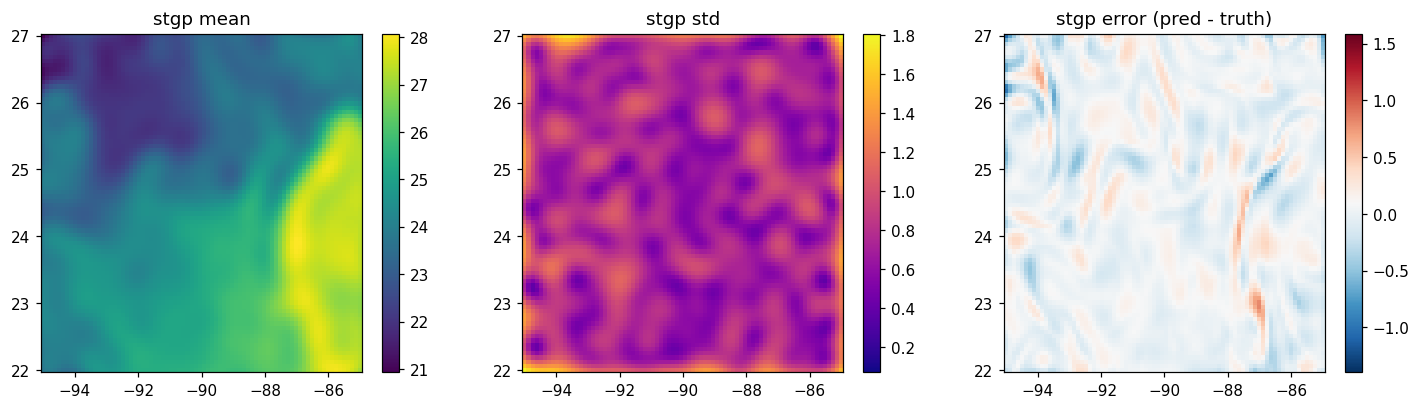

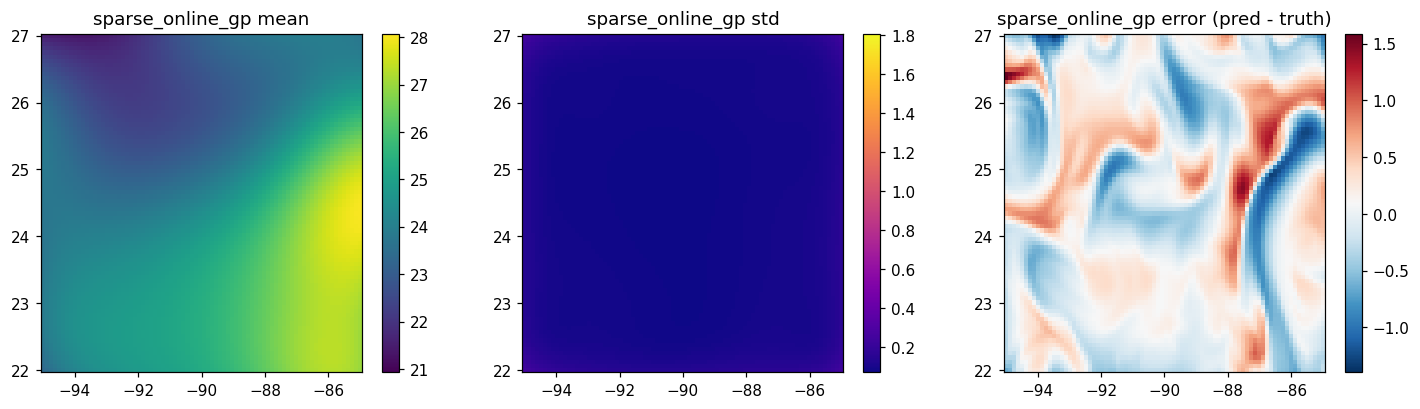

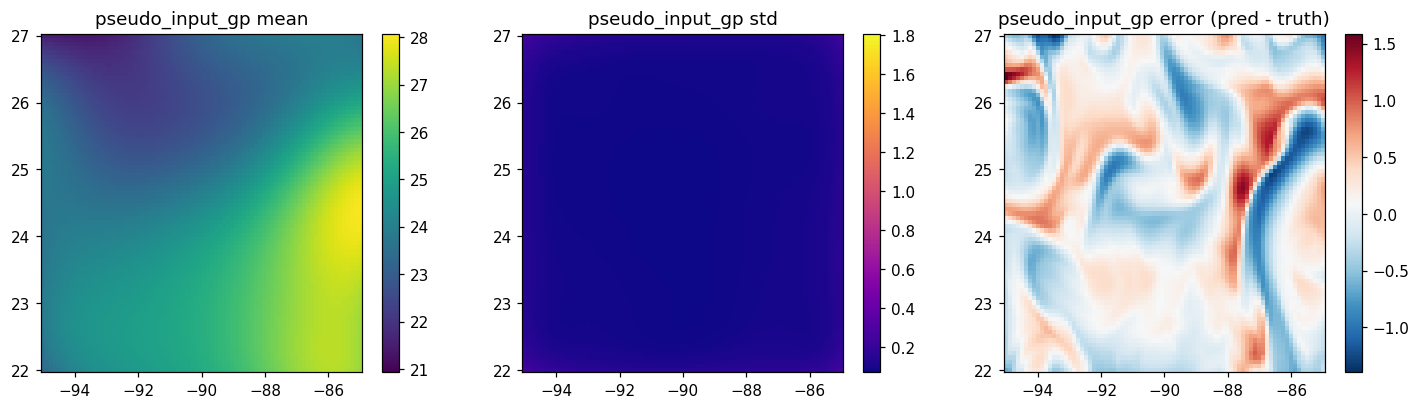

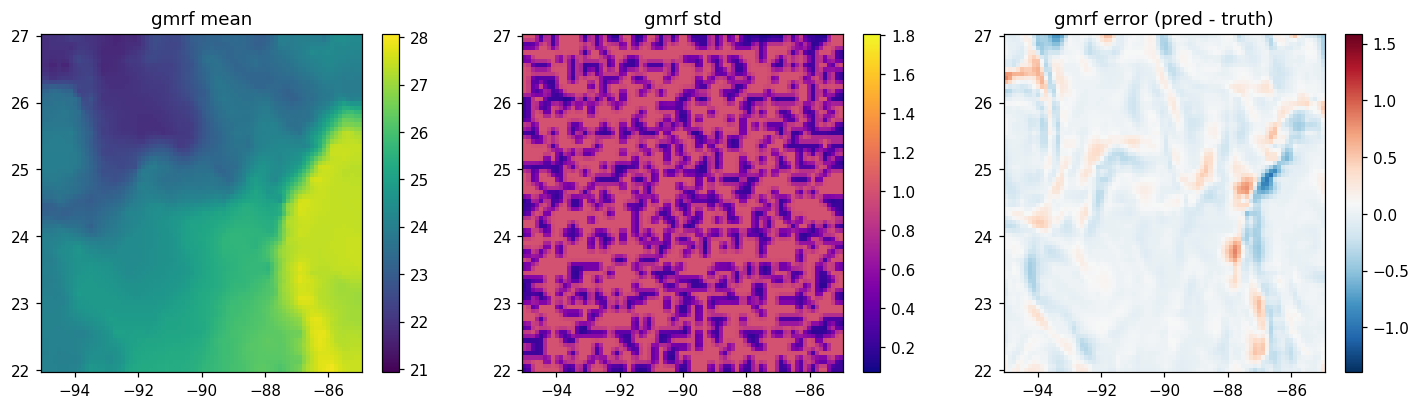

In [149]:
# mask: True where truth is missing
truth_mask = ~np.isfinite(Y_grid_true)

for name in results:
    Y_pred = results[name]['Y_grid_pred']
    Y_std = results[name]['Y_grid_std']
    err = Y_pred - Y_grid_true

    # Error only where truth exists
    err_masked = np.ma.masked_where(truth_mask, err)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # mean over full domain
    pc0 = axes[0].pcolormesh(
        GridLon, GridLat, Y_pred,
        shading='auto', cmap='viridis',
        vmin=mean_vmin, vmax=mean_vmax,
    )
    axes[0].set_title(f'{name} mean')
    plt.colorbar(pc0, ax=axes[0])

    # std over full domain (when available)
    if Y_std is not None and std_vmax is not None:
        pc1 = axes[1].pcolormesh(
            GridLon, GridLat, Y_std,
            shading='auto', cmap='plasma',
            vmin=std_vmin, vmax=std_vmax,
        )
        axes[1].set_title(f'{name} std')
        plt.colorbar(pc1, ax=axes[1])
    else:
        axes[1].axis('off')
        axes[1].set_title(f'{name} std (not available)')

    # error only where truth exists
    pc2 = axes[2].pcolormesh(
        GridLon, GridLat, err_masked,
        shading='auto', cmap='RdBu_r',
        vmin=err_vmin, vmax=err_vmax,
    )
    axes[2].set_title(f'{name} error (pred - truth)')
    plt.colorbar(pc2, ax=axes[2])